# DPN for Binary Classification Classes

In [ ]:
import json
import seaborn as sns
import warnings
import time
from pprint import pprint

import dice_ml
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb



from CEval import CEval
#. from module.dataload import DPN_data
#. from module.eda import EDA
#. from module.eda import EDAHelper



In [2]:
#. 
import sys 
sys.path.append('..')  

from module.backends.backend_adapter import get_dice_components
from module.models.optimizers import grid_search_cv_binary
from module.dataload import DPN_data
from module.eda import EDA


In [3]:
warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Full Features

### Data Loading

Binary Classification Classes:  ['Negative', 'Possible', 'Probable'] vs 'Confirmed'


In [17]:
D = DPN_data("../dataset/Sudoscan Working File with Stats.xlsx")
D.load(classification="binary")
D.load()

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,64.0,1,7.0,1.0,15.00,0,0,0,0,0,1,1,1,1,9.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0,1
1,0,59.0,1,1.0,0.0,5.60,1,0,0,0,0,0,0,0,0,4.0,19.41,52.30,14.21,61.90,49.3,3.55,14.34,10.55,42.50,19.54,55.7,15.09,61.20,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0,0
2,0,64.0,1,11.0,1.0,7.50,1,0,0,0,0,1,1,1,1,5.0,0.00,0.00,0.00,0.00,35.9,4.35,1.83,1.29,54.40,0.00,0.0,0.00,0.00,36.2,4.70,2.40,1.92,54.7,65.0,14.0,79.0,1.0,50.0,33.0,1
3,0,53.0,1,10.0,1.0,7.60,1,0,1,0,0,1,0,0,0,8.0,7.86,46.70,7.07,42.50,40.4,4.30,6.08,4.20,51.00,8.98,48.7,8.08,42.70,40.0,4.25,7.81,6.18,50.9,43.0,10.0,49.0,5.0,57.0,33.0,1
4,1,57.0,0,5.0,1.0,14.40,0,0,0,0,0,1,0,1,1,1.0,4.19,41.90,3.70,38.20,38.5,4.50,8.89,6.88,48.30,5.36,45.5,4.42,39.50,38.3,4.00,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0,1
5,0,20.0,1,2.0,1.0,7.80,0,0,0,0,0,0,0,1,0,0.0,26.55,47.40,14.42,49.60,45.4,3.75,17.17,11.36,49.40,32.17,46.3,16.06,44.10,42.2,3.35,21.26,15.37,50.3,67.0,4.0,80.0,4.0,99.0,0.0,0
6,0,69.0,0,0.0,0.0,8.00,1,0,1,0,0,0,1,0,0,1.0,11.40,51.70,17.16,54.50,44.7,3.20,13.69,10.06,46.40,12.56,48.7,13.61,53.40,48.4,3.70,13.51,8.37,46.6,74.0,1.0,77.0,6.0,49.0,33.0,0
7,0,60.0,0,2.0,0.0,5.80,1,0,0,0,0,1,0,0,0,5.0,19.46,49.60,7.46,49.60,42.3,3.30,13.74,10.44,47.00,19.50,46.2,9.84,40.10,43.8,3.40,13.55,10.87,46.9,63.0,4.0,65.0,11.0,54.0,29.0,0
8,1,62.0,0,0.0,1.0,14.36,0,0,0,0,0,1,1,1,0,3.0,8.36,45.10,0.00,0.00,36.4,3.75,9.20,6.53,56.10,7.58,44.6,0.00,0.00,35.7,3.95,9.42,7.25,57.2,72.0,2.0,61.0,19.0,56.0,31.0,1
9,0,44.0,1,17.0,0.0,7.01,0,0,0,0,0,1,1,1,1,10.0,1.13,46.90,0.00,0.00,36.6,5.10,4.22,2.52,56.60,1.26,42.4,0.00,0.00,35.6,4.75,4.02,2.09,55.4,19.0,10.0,84.0,1.0,64.0,18.0,1


In [18]:
df = D.df
data_cols = df.drop(D.non_data_cols, axis=1, errors="ignore").columns
len(data_cols), data_cols

(40,
 Index(['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD',
        'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR',
        'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L',
        'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R',
        'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R',
        'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM',
        'NS', 'CAS'],
       dtype='object'))

### Data Inspection

In [20]:
X = df[data_cols]
y = df['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

### Set Global Variables

In [22]:
test_size = 0.25
verbosity = 1

### Train Test Split

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=0, stratify=y)

### Colinear Feature Elimination

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Example: df is your DataFrame with predictors
X2 = X.copy()

# Add constant term (intercept) for statsmodels
X2 = add_constant(X2)

# Compute VIF for each column
vif_data = pd.DataFrame()
vif_data["feature"] = X2.columns
vif_data["VIF"] = [variance_inflation_factor(X2.values, i) 
                   for i in range(X2.shape[1])]
high_vif = vif_data[vif_data["VIF"]>5]
print(high_vif)

      feature      VIF
0       const  433.829
17      SSA_L    6.858
18      SSC_L    6.793
20     SPSC_L   12.951
23  CMAPANK_L   30.508
24  CMAPKNE_L   30.224
26      SSA_R    5.531
27      SSC_R    5.805
28     SPSA_R    7.522
29     SPSC_R   11.552
32  CMAPANK_R   25.286
33  CMAPKNE_R   25.184


In [25]:
# drop these features which seem to be collinear
high_vif_features = ['SSA_L','SSC_L','SPSC_L','CMAPANK_L','CMAPKNE_L','SPSA_R', 'CMAPKNE_R']

In [29]:
#. pruned_df = df.drop(columns=features_to_drop)
pruned_df = df.drop(columns=high_vif_features) #.

X_pr = pruned_df.drop(columns=['Confirmed_Binary_DPN'])
y_pr = pruned_df['Confirmed_Binary_DPN']

X_pr_train, X_pr_val, y_pr_train, y_pr_val = train_test_split(X_pr, y_pr, test_size=test_size, random_state=0, stratify=y)

In [30]:
def set_splits(model_name):
    #. perform pruning for all models
    return X_pr_train, y_pr_train, X_pr_val, y_pr_val #.

    # if model_name == "logistic_regression":
    #     return X_pr_train, y_pr_train, X_pr_val, y_pr_val
    # else:
    #     return X_train, y_train, X_val, y_val

In [31]:
def get_metrics(models):
    model_runs = {}
    for model_name, model in models.items():

        X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

        stats = EDA.binary_classification_metrics(
            confusion_matrix(
                y_val_temp,
                model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
            ),
            #. labels=D.binary_class_label, verbosity=verbosity)
            labels=D.binary_classes_labels, verbosity=verbosity)

        if verbosity > 0:
            print(model_name, '---------') 
            pprint(stats)
            print('---------')

        model_runs[model_name] = stats

    return model_runs

### DICT OF INITIAL MODELS

Logistic Regression Scaling

In [15]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [16]:
initial_models = {
    "dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

### RUNNING EACH MODEL

In [17]:
verbosity = 0    
initial_model_runs = get_metrics(initial_models)
#pprint(initial_model_runs)
pd.DataFrame(initial_model_runs)

,dummy,random_forest,decision_tree,xgb,logistic_regression
sensitivity,1.000,0.970,0.909,0.970,0.909
specificity,0.000,0.867,0.667,0.667,0.733
youden_index,0.000,0.836,0.576,0.636,0.642
accuracy,0.688,0.938,0.833,0.875,0.854


### BINARY GRID SEARCH CV

DICT OF ESTIMATORS

In [18]:
logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('classifier', LogisticRegression())
])

In [19]:
estimators = {
    #"dummy": DummyClassifier(),
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier(),
    "xgb": xgb.XGBClassifier(),
    "logistic_regression": logistic_regression
}

LOADING PARAMETER GRIDS FROM JSON

In [20]:
# LOADING JSON FILE STORING PARAMETER CONFIGURATIONS
with open('model_configs/param_grids/binary_param_grids.json', 'r') as file:
    param_grids = json.load(file)

In [21]:
param_grids

{'xgb': {'booster': ['gbtree'],
  'device': ['cpu'],
  'verbosity': [1],
  'validate_parameters': [False],
  'nthread': [None],
  'disable_default_eval_metric': [False],
  'objective': ['binary:logistic'],
  'eta': [0.5, 1.0],
  'gamma': [0, 0.5, 5],
  'max_depth': [6, 3, 9],
  'min_child_weight': [1, 5],
  'max_delta_step': [0, 1, 5],
  'subsample': [1.0, 0, 0.01, 0.4, 0.8],
  'sampling_method': ['uniform'],
  'colsample_bytree': [0.5, 0, 1.0],
  'colsample_bylevel': [0.5, 0, 1.0],
  'colsample_bynode': [0.5, 0, 1.0],
  'lambda': [1, 0, 3, 5],
  'alpha': [0, 1, 3, 5],
  'tree_method': ['auto', 'exact'],
  'scale_pos_weight': [1, 5, 10],
  'process_type': ['default'],
  'grow_policy': ['depthwise', 'lossguide'],
  'max_leaves': [0, 8, 16],
  'num_parallel_tree': [1, 5, 10],
  'max_bin': [16, 64]},
 'random_forest': {'n_estimators': [100, 200, 500],
  'criterion': ['gini', 'entropy'],
  'max_depth': [None, 10, 20, 30],
  'min_samples_split': [2, 5, 10],
  'min_samples_leaf': [1, 2, 4],


### RUNNING BINARY GRID SEARCH CV ON EACH ESTIMATOR

In [22]:
optimized_params = {}

start_time = time.time()

# CONDUCTING GRID_SEARCH_CV ON THE BINARY CLASSIFICATION MODELS
for estimator_name, estimator in estimators.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(estimator_name)
    
    params = grid_search_cv_binary(
        estimator,
        param_grids.get(estimator_name, {}),
        (X_train_temp, y_train_temp),
        scoring='youden_index',
        verbosity=verbosity,
        cv_splits=5
    )

    print("Optimized parameters for {}: {}".format(estimator_name, params))

    optimized_params[estimator_name] = params.best_params_

end_time = time.time()

pprint(optimized_params)

print(f"Grid Search finished in {end_time - start_time} seconds")

Optimized parameters for random_forest: RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=100,
                   param_distributions={'bootstrap': [True, False],
                                        'class_weight': [None, 'balanced',
                                                         'balanced_subsample'],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', 0.8],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 500],
                                        'random_state': [42]},
                   random_state=42,
                   scoring=make_scorer(get_binary_score_cv, response_method='predict'))
Optimized parameters for decision_

In [29]:
optimized_params['xgb']

{'verbosity': 1,
 'validate_parameters': False,
 'tree_method': 'auto',
 'subsample': 0.8,
 'scale_pos_weight': 1,
 'sampling_method': 'uniform',
 'process_type': 'default',
 'objective': 'binary:logistic',
 'num_parallel_tree': 1,
 'nthread': None,
 'min_child_weight': 1,
 'max_leaves': 0,
 'max_depth': 6,
 'max_delta_step': 5,
 'max_bin': 64,
 'lambda': 0,
 'grow_policy': 'depthwise',
 'gamma': 0.5,
 'eta': 0.5,
 'disable_default_eval_metric': False,
 'device': 'cpu',
 'colsample_bytree': 1.0,
 'colsample_bynode': 0,
 'colsample_bylevel': 0.5,
 'booster': 'gbtree',
 'alpha': 0}

### DICT OF OPTIMIZED MODELS

Generated parameter set is inputted into the classifiers as kwargs

In [30]:
#.
def strip_classifier_prefix(params):
    return {k.replace('classifier__', ''): v for k, v in params.items()}
logreg_params = strip_classifier_prefix(optimized_params["logistic_regression"])
#.

logistic_regression = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    #. ('classifier', LogisticRegression(**optimized_params["logistic_regression"]))
    ('classifier', LogisticRegression(**logreg_params)) #.
])

In [31]:
optimized_models = {
    "xgb": xgb.XGBClassifier(**optimized_params["xgb"]),
    "random_forest": RandomForestClassifier(**optimized_params["random_forest"]),
    "decision_tree": DecisionTreeClassifier(**optimized_params["decision_tree"]),
    "logistic_regression": logistic_regression
}

In [32]:
best_youden = (None, 0)

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    stats = EDA.binary_classification_metrics(
        confusion_matrix(
            y_val_temp,
            model.fit(X_train_temp, y_train_temp).predict(X_val_temp)
        ),
        labels=D.binary_classes_labels, verbosity=verbosity)

    print(f"Statistics for optimized {model_name} model")
    best_youden = (model_name, stats['youden_index']) if stats['youden_index'] > best_youden[1] else best_youden
    pprint(stats)
    
print(f"The best model is: {best_youden[0]} with a youden_index of {best_youden[1]}")

Statistics for optimized xgb model
{'accuracy': 0.875,
 'sensitivity': 0.9393939393939394,
 'specificity': 0.7333333333333333,
 'youden_index': 0.6727272727272728}
Statistics for optimized random_forest model
{'accuracy': 0.9166666666666666,
 'sensitivity': 0.9393939393939394,
 'specificity': 0.8666666666666667,
 'youden_index': 0.8060606060606061}
Statistics for optimized decision_tree model
{'accuracy': 0.8541666666666666,
 'sensitivity': 0.8787878787878788,
 'specificity': 0.8,
 'youden_index': 0.6787878787878787}
Statistics for optimized logistic_regression model
{'accuracy': 0.875,
 'sensitivity': 0.9090909090909091,
 'specificity': 0.8,
 'youden_index': 0.709090909090909}
The best model is: random_forest with a youden_index of 0.8060606060606061


In [33]:
optimized_model_runs = get_metrics(optimized_models)
pprint(optimized_model_runs)

{'decision_tree': {'accuracy': 0.8541666666666666,
                   'sensitivity': 0.8787878787878788,
                   'specificity': 0.8,
                   'youden_index': 0.6787878787878787},
 'logistic_regression': {'accuracy': 0.875,
                         'sensitivity': 0.9090909090909091,
                         'specificity': 0.8,
                         'youden_index': 0.709090909090909},
 'random_forest': {'accuracy': 0.9166666666666666,
                   'sensitivity': 0.9393939393939394,
                   'specificity': 0.8666666666666667,
                   'youden_index': 0.8060606060606061},
 'xgb': {'accuracy': 0.875,
         'sensitivity': 0.9393939393939394,
         'specificity': 0.7333333333333333,
         'youden_index': 0.6727272727272728}}


In [35]:
from utils.plotting_helper import display_binary_model_metrics
pd.DataFrame(optimized_model_runs)
#display_binary_model_metrics(optimized_model_runs)

,xgb,random_forest,decision_tree,logistic_regression
sensitivity,0.939,0.939,0.879,0.909
specificity,0.733,0.867,0.800,0.800
youden_index,0.673,0.806,0.679,0.709
accuracy,0.875,0.917,0.854,0.875


In [36]:
## Save optimized parameters, models, and statistics

import joblib
joblib.dump(optimized_params, "optimized_models\optimized_models_params.pkl")
joblib.dump(optimized_models, "optimized_models\optimized_models.pkl")
joblib.dump(optimized_model_runs, "optimized_models\optimized_models_metrics.pkl")


['optimized_models\\optimized_models_metrics.pkl']

### Generating Counterfactuals for Each Model

In [ ]:
cf_explainers = {}

for model_name, model in optimized_models.items():

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
    y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)

    df_temp = pd.concat([X_temp, y_temp], axis=1)

    model.fit(X_train_temp, y_train_temp)
    
    d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
    m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
    
    exp = dice_ml.Dice(d, m, method="genetic")
    
    print(f"generating counterfactuals for the {model_name} model")
    
    e1 = exp.generate_counterfactuals(
        X_val_temp, total_CFs=3, desired_class="opposite")
    
    cf_explainers[model_name] = e1

generating counterfactuals for the xgb model


100%|██████████| 48/48 [00:11<00:00,  4.25it/s]


generating counterfactuals for the random_forest model


100%|██████████| 48/48 [00:10<00:00,  4.37it/s]


generating counterfactuals for the decision_tree model


100%|██████████| 48/48 [00:04<00:00, 10.03it/s]


generating counterfactuals for the logistic_regression model


100%|██████████| 48/48 [00:07<00:00,  6.57it/s]


In [ ]:
# Define a simple distance function (Euclidean distance)
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

dist = euclidean_distance

constraints = [
    {'feature': 0, 'type': 'unchanged', 'action': 'increase'},
    {'feature': 1, 'type': 'unchanged', 'action': 'increase'}
]

In [ ]:
cf_explainers[best_youden[0]].visualize_as_dataframe(show_only_changes=True)

Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,6.0,0.0,6.6,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,6.0,8.97,48.7,50.0,5.45,3.43,53.4,37.6,4.55,55.0,55.0,22.0,64.0,3.0,49.0,32.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,2.0,-,0.0,-,-,-,-,-,-,-,-,0.0,5.0,10.5,49.6,49.6,3.3,9.67,47.0,43.8,0.0,46.9,63.0,-,68.0,2.0,57.0,0.0,0.0
0,-,-,10.0,-,5.7,-,-,-,-,-,0.0,1.0,-,-,5.0,10.5,43.4,46.9,4.1,9.67,45.1,44.3,4.1,45.9,32.0,-,68.0,2.0,57.0,27.0,0.0
0,-,-,0.0,-,6.1,-,-,-,-,-,0.0,-,-,0.0,4.0,21.6,51.2,53.8,3.15,11.6,48.3,43.7,3.3,46.9,45.0,0.0,44.0,6.0,50.0,-,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,11.0,1.0,7.5,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0,0.0,0.0,0.0,4.35,1.29,54.4,36.2,4.7,54.7,65.0,14.0,79.0,1.0,50.0,33.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,20.0,-,6.3,-,-,1.0,-,-,-,-,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,-,9.0,43.0,44.0,0.0
0,-,-,10.0,0.0,5.7,-,-,-,-,-,0.0,-,0.0,-,-,10.5,43.4,46.9,4.1,9.67,45.1,44.3,4.1,45.9,32.0,22.0,68.0,2.0,57.0,27.0,0.0
0,-,-,6.0,-,11.2,0.0,-,-,-,-,-,-,0.0,0.0,-,18.8,45.9,44.2,3.65,9.57,47.4,50.8,4.8,48.8,75.0,1.0,76.0,3.0,76.0,31.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,0.0,1.0,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.57,50.0,50.0,3.15,6.69,43.5,49.0,3.3,43.9,45.0,10.0,24.0,8.0,77.0,11.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,0.0,0.0,0.0,-,-,-,-,-,-,-,-,-,-,0.0,38.3,0.0,0.0,0.0,0.0,38.4,3.6,0.0,6.0,0.0,8.0,0.0,0.0,29.0,1.0
0,-,-,0.0,0.0,0.0,-,-,-,-,-,-,-,-,-,-,0.0,48.7,48.0,0.0,3.02,41.3,38.4,0.0,0.0,31.0,0.0,31.0,39.0,0.0,0.0,1.0
0,-,-,0.0,0.0,0.0,-,-,-,-,-,-,-,-,-,-,0.0,48.7,0.0,0.0,0.0,41.3,38.4,0.0,0.0,31.0,0.0,31.0,0.0,43.0,0.0,1.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,0.0,1.0,12.52,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,16.67,46.9,53.4,3.4,8.58,42.2,49.6,3.6,41.7,60.0,0.0,46.0,0.0,80.0,25.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,-,0.0,9.4,-,-,-,-,-,-,1.0,-,-,3.0,13.3,40.1,40.1,4.15,3.03,50.9,42.9,3.6,51.6,6.0,1.0,67.0,-,0.0,29.0,1.0
0,-,-,-,-,10.4,-,-,-,-,-,-,-,0.0,1.0,3.0,4.3,48.0,47.7,0.0,5.52,0.0,39.1,3.2,0.0,55.0,-,85.0,4.0,64.0,-,1.0
0,-,-,1.0,-,11.1,-,-,-,-,-,1.0,-,-,-,3.0,8.1,40.1,40.1,4.15,3.03,50.9,36.6,3.9,51.6,54.0,5.0,67.0,7.0,46.0,30.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,0.0,10.0,0.0,6.4,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,8.85,44.5,39.0,4.4,5.52,51.2,34.8,4.4,52.7,6.0,14.0,38.0,25.0,54.0,33.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,2.0,-,5.8,-,-,-,0.0,-,-,-,-,-,0.0,10.1,0.0,59.6,3.25,10.44,47.0,47.6,3.6,0.0,63.0,4.0,52.0,11.0,50.0,37.0,0.0
0,-,-,2.0,-,5.8,-,-,-,0.0,-,-,-,0.0,-,1.0,0.0,49.6,49.6,3.3,7.51,47.0,44.4,3.4,46.9,60.0,0.0,44.0,54.0,57.0,29.0,0.0
0,-,-,4.0,-,5.8,-,-,-,0.0,-,0.0,-,-,-,0.0,23.6,51.5,0.0,3.15,0.0,47.0,47.6,3.6,0.0,63.0,0.0,24.0,0.0,0.0,37.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,10.0,0.0,7.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,24.94,50.0,51.3,3.35,11.95,44.6,46.9,4.05,44.2,65.0,7.0,80.0,2.0,41.0,31.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,0.0,-,-,0.0,-,-,-,-,-,-,-,0.0,-,4.0,6.6,53.4,43.4,3.8,4.12,52.2,40.1,3.5,54.9,81.0,-,8.0,-,62.0,0.0,1.0
0,-,-,-,1.0,6.9,-,-,-,-,-,-,-,0.0,-,7.0,8.9,53.4,52.4,3.8,4.12,52.2,41.1,3.5,47.4,81.0,4.0,85.0,-,62.0,32.0,1.0
0,-,-,8.0,-,11.1,-,-,-,-,-,-,1.0,-,-,0.0,11.2,40.1,51.8,0.0,0.0,50.9,36.6,3.9,51.6,71.0,1.0,66.0,0.0,0.0,30.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,0.0,0.0,9.4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,8.0,13.28,50.0,55.8,3.55,5.65,45.9,42.9,3.6,46.3,52.0,1.0,53.0,39.0,50.0,29.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,4.0,-,10.5,0.0,-,-,-,-,-,-,-,-,3.0,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,-,37.0,0.0
0,-,-,1.0,-,6.4,-,-,-,-,-,0.0,-,0.0,0.0,2.0,12.3,45.3,52.6,3.85,7.8,48.8,44.6,3.9,0.0,75.0,-,50.0,15.0,57.0,-,0.0
0,-,-,-,-,5.8,0.0,-,-,-,-,-,0.0,0.0,0.0,0.0,19.5,51.2,53.8,3.3,11.6,48.3,43.8,3.3,46.9,63.0,0.0,65.0,11.0,-,-,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,1.0,0.0,8.7,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,5.0,3.69,56.2,37.2,4.1,55.6,15.0,12.0,63.0,14.0,47.0,36.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,30.0,-,4.9,-,-,-,-,-,0.0,-,-,-,4.0,14.4,47.6,45.5,3.95,7.78,46.4,42.3,3.5,46.6,46.0,0.0,60.0,0.0,34.0,30.0,0.0
0,-,-,20.0,1.0,6.3,-,-,-,-,-,-,-,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,-,-,4.0,-,10.5,0.0,-,0.0,-,-,-,-,-,-,3.0,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,1.0,0.0,8.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,22.45,55.9,46.7,3.8,7.57,46.4,54.0,4.45,46.5,71.0,4.0,74.0,0.0,68.0,21.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,0.0,-,17.6,-,-,-,-,-,-,-,-,-,-,13.4,48.2,46.7,4.75,1.27,59.3,36.1,4.0,60.6,61.0,9.0,72.0,10.0,63.0,25.0,1.0
0,-,-,6.0,-,0.0,-,-,-,-,-,-,-,-,-,5.0,11.2,49.2,45.5,3.8,6.05,54.7,0.0,3.9,56.7,47.0,1.0,58.0,-,72.0,26.0,1.0
0,-,-,6.0,-,8.6,-,-,-,-,-,-,-,-,-,8.0,11.2,42.4,42.3,3.8,5.24,50.7,41.0,3.9,52.3,59.0,1.0,78.0,5.0,72.0,24.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,10.0,0.0,6.1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,9.0,12.23,50.4,45.5,3.45,6.6,51.6,53.0,4.25,51.2,55.0,1.0,49.0,15.0,55.0,24.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,0.0,-,6.1,-,-,-,-,-,-,-,0.0,-,3.0,21.6,51.2,0.0,3.25,11.6,0.0,0.0,3.6,46.0,40.0,9.0,44.0,5.0,50.0,37.0,0.0
0,-,-,17.0,-,6.4,-,-,-,-,-,0.0,-,-,-,5.0,18.6,52.4,46.7,2.95,7.08,38.8,51.2,2.8,39.1,46.0,6.0,71.0,5.0,42.0,31.0,0.0
0,-,-,1.0,-,10.3,-,-,-,-,-,0.0,-,-,-,11.0,0.0,52.3,61.9,3.4,9.53,0.0,0.0,3.3,43.3,72.0,0.0,70.0,28.0,0.0,39.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,4.0,0.0,5.9,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,7.0,0.0,0.0,47.8,4.15,6.53,52.1,40.9,4.1,51.4,56.0,14.0,63.0,18.0,39.0,18.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,0.0,-,6.9,-,-,-,-,-,-,-,-,0.0,8.0,11.8,48.4,49.1,3.85,7.6,48.2,46.6,3.5,47.8,58.0,6.0,52.0,5.0,46.0,47.0,0.0
0,0.0,-,0.0,-,4.8,-,-,0.0,-,-,-,-,-,-,6.0,21.3,41.7,40.0,4.45,10.01,53.4,40.2,4.6,52.8,17.0,25.0,42.0,6.0,-,32.0,0.0
0,0.0,-,9.0,-,7.4,0.0,-,-,-,-,0.0,-,-,-,6.0,12.8,49.2,40.3,4.4,7.39,54.0,45.2,4.0,55.7,49.0,2.0,59.0,10.0,63.0,29.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,24.0,1.0,7.4,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0,0.0,0.0,0.0,3.55,2.68,48.1,36.0,3.25,48.4,29.0,6.0,70.0,12.0,62.0,26.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,20.0,-,6.3,-,-,1.0,-,-,-,-,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,-,-,4.0,0.0,10.5,0.0,-,-,-,-,-,-,-,-,3.0,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0
0,-,-,10.0,0.0,5.7,-,-,-,-,-,0.0,-,0.0,-,-,10.5,43.4,46.9,4.1,9.67,45.1,44.3,4.1,45.9,32.0,22.0,68.0,2.0,57.0,27.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,3.0,0.0,6.8,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,3.0,6.44,44.7,42.2,4.35,4.53,45.7,46.3,5.1,44.7,13.0,7.0,48.0,18.0,48.0,32.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,4.0,-,10.5,-,-,0.0,-,-,-,-,1.0,-,-,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0
0,-,-,0.0,-,0.0,-,-,0.0,-,-,-,0.0,-,-,0.0,21.3,41.7,50.0,3.15,10.01,53.4,49.0,3.3,43.9,17.0,10.0,42.0,0.0,77.0,-,0.0
0,-,-,0.0,-,7.4,-,-,-,-,-,0.0,0.0,-,-,6.0,12.8,49.2,40.3,4.4,7.39,54.0,45.2,4.0,55.7,49.0,2.0,59.0,10.0,63.0,29.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,0.0,14.0,0.0,6.64,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.27,50.4,46.7,3.85,4.33,52.5,48.3,5.0,53.4,54.0,24.0,71.0,9.0,44.0,37.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,7.0,-,7.3,-,-,1.0,0.0,-,0.0,-,-,-,-,15.6,51.8,53.0,3.9,9.36,44.7,53.2,4.2,44.8,48.0,13.0,56.0,8.0,59.0,44.0,0.0
0,-,1.0,4.0,-,7.9,0.0,-,-,-,-,-,-,-,0.0,7.0,11.9,46.5,47.4,4.25,7.08,52.8,41.9,3.8,54.4,38.0,2.0,51.0,-,34.0,30.0,0.0
0,0.0,-,4.0,1.0,10.5,-,-,-,-,-,-,-,1.0,-,3.0,0.0,0.0,59.6,3.25,7.16,45.1,44.6,0.0,0.0,40.0,0.0,-,5.0,57.0,29.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,0.0,0.0,6.3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,16.49,50.4,48.1,3.9,4.53,42.0,42.2,3.6,41.7,77.0,0.0,73.0,10.0,88.0,24.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,-,-,0.0,-,-,-,-,-,-,-,-,-,4.0,5.8,49.6,47.7,4.75,0.0,0.0,41.5,4.0,60.6,61.0,-,58.0,7.0,0.0,46.0,1.0
0,-,-,-,-,11.4,-,-,-,-,-,-,-,-,-,0.0,0.0,43.9,46.5,5.25,0.0,0.0,42.3,4.2,0.0,66.0,-,64.0,13.0,56.0,31.0,1.0
0,-,-,-,-,17.6,-,-,-,-,-,-,-,-,-,5.0,6.7,0.0,46.5,4.75,0.0,59.3,36.1,4.0,60.6,47.0,4.0,8.0,-,0.0,0.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,20.0,1.0,7.9,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,8.0,4.77,43.1,41.2,4.25,3.63,48.7,40.5,3.9,47.3,56.0,17.0,75.0,11.0,49.0,32.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,4.0,0.0,10.5,-,0.0,-,0.0,0.0,-,-,-,-,3.0,22.5,51.5,59.6,3.25,7.57,0.0,0.0,4.4,46.0,71.0,9.0,52.0,5.0,50.0,37.0,0.0
0,-,-,-,-,6.9,-,0.0,1.0,-,0.0,-,-,1.0,0.0,7.0,19.2,54.7,52.3,3.5,7.31,46.8,45.3,3.4,45.1,46.0,8.0,55.0,16.0,41.0,47.0,0.0
0,-,-,10.0,0.0,5.7,-,0.0,-,0.0,0.0,-,1.0,-,-,5.0,10.5,43.4,46.9,4.1,9.67,45.1,44.3,4.1,45.9,32.0,22.0,68.0,2.0,57.0,27.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,1.0,0.0,12.64,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,7.0,0.0,0.0,0.0,4.9,6.25,56.1,39.5,4.65,57.1,48.0,6.0,61.0,10.0,58.0,29.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,9.0,-,7.4,-,-,-,-,-,0.0,0.0,0.0,-,6.0,12.8,49.2,40.3,4.4,7.39,54.0,45.2,4.0,55.7,49.0,2.0,59.0,-,63.0,-,0.0
0,-,-,2.0,-,5.2,-,-,-,-,-,0.0,0.0,-,0.0,9.0,12.2,2.0,2.4,4.15,8.91,43.3,49.3,3.5,42.9,57.0,-,50.0,7.0,70.0,-,0.0
0,-,-,-,1.0,10.3,1.0,-,-,-,-,0.0,-,-,-,4.0,17.6,-,58.1,3.4,7.16,0.0,46.1,4.1,49.7,72.0,0.0,70.0,5.0,0.0,27.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,2.0,0.0,9.7,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,7.0,4.78,28.6,0.0,4.4,1.64,58.5,27.8,3.75,60.2,76.0,1.0,49.0,11.0,57.0,30.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,-,9.0,-,7.4,-,-,-,-,-,0.0,-,-,-,6.0,12.8,49.2,40.3,4.4,7.39,54.0,45.2,4.0,55.7,49.0,2.0,59.0,10.0,63.0,29.0,0.0
0,-,-,0.0,-,6.9,1.0,-,-,-,-,-,-,-,0.0,8.0,11.8,48.4,49.1,3.85,7.6,48.2,46.6,3.5,47.8,58.0,6.0,52.0,5.0,46.0,47.0,0.0
0,-,-,4.0,-,7.9,-,-,0.0,1.0,-,-,1.0,-,0.0,-,11.9,46.5,47.4,4.25,7.08,52.8,41.9,3.8,54.4,38.0,2.0,51.0,9.0,34.0,-,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,6.0,1.0,12.36,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,21.31,54.2,51.4,3.6,8.15,45.1,41.3,3.6,45.5,75.0,3.0,72.0,1.0,74.0,15.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,7.0,-,10.4,-,-,-,-,-,-,-,-,-,9.0,8.6,0.0,47.7,0.0,6.6,51.6,53.0,3.2,51.2,55.0,0.0,49.0,15.0,52.0,0.0,1.0
0,-,-,5.0,-,7.5,0.0,-,-,-,-,-,-,-,-,-,9.3,46.9,41.8,5.6,1.39,54.7,32.9,3.2,50.6,64.0,12.0,8.0,7.0,0.0,46.0,1.0
0,1.0,-,5.0,-,9.7,-,-,-,-,-,-,-,0.0,-,5.0,10.4,47.0,48.7,3.7,5.15,52.8,41.1,4.0,51.0,73.0,1.0,83.0,-,60.0,35.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,14.0,1.0,10.33,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,11.05,49.1,43.5,3.45,3.99,48.3,41.7,3.45,47.9,83.0,3.0,87.0,2.0,84.0,17.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,2.0,-,9.4,-,-,-,-,-,-,-,-,-,9.0,17.0,52.1,46.6,3.05,7.08,51.0,41.0,2.7,50.4,64.0,0.0,-,0.0,81.0,13.0,0.0
0,-,-,25.0,-,9.2,-,-,-,-,-,-,1.0,-,-,11.0,16.4,49.5,45.5,3.4,9.53,49.2,42.0,4.8,48.4,48.0,0.0,70.0,0.0,0.0,0.0,0.0
0,-,0.0,0.0,0.0,6.6,-,-,-,-,-,-,-,-,-,2.0,15.5,44.5,41.7,4.5,5.43,51.6,41.7,4.6,51.7,81.0,-,79.0,8.0,74.0,20.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,6.0,0.0,9.07,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,7.0,13.14,49.7,46.5,3.85,3.45,53.3,40.0,15.15,53.1,78.0,3.0,84.0,3.0,73.0,21.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,0.0,0.0,-,6.6,-,-,-,-,-,0.0,-,-,-,2.0,15.5,44.5,41.7,4.5,5.43,51.6,41.7,4.6,51.7,81.0,-,79.0,8.0,74.0,20.0,0.0
0,-,-,1.0,-,8.0,1.0,-,-,-,-,0.0,-,-,-,4.0,22.5,55.9,46.7,3.8,7.57,46.4,54.0,4.4,46.5,71.0,4.0,74.0,0.0,68.0,-,0.0
0,-,-,0.0,-,6.4,-,-,0.0,-,-,0.0,-,-,-,4.0,22.5,56.6,0.0,4.05,7.8,46.3,54.0,3.9,46.5,58.0,0.0,8.0,0.0,0.0,-,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,1.0,0.0,5.59,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,5.0,0.0,0.0,0.0,4.9,0.51,55.7,38.2,4.0,0.0,27.0,20.0,34.0,27.0,44.0,37.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,-,0.0,-,4.8,-,-,-,0.0,-,-,-,-,-,4.0,-,51.2,-,3.3,10.44,53.4,44.6,4.1,46.9,17.0,1.0,71.0,11.0,54.0,32.0,0.0
0,-,-,-,-,11.0,0.0,-,-,0.0,-,-,-,-,-,-,12.1,47.5,42.0,3.5,7.21,52.6,40.3,3.8,52.7,37.0,5.0,46.0,14.0,76.0,7.0,0.0
0,0.0,-,0.0,-,10.5,-,-,-,0.0,-,-,-,0.0,-,6.0,-,51.5,-,3.5,8.99,42.5,47.6,0.0,46.0,40.0,9.0,22.0,0.0,60.0,-,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,0.0,0.0,1.0,14.36,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0,8.36,45.1,0.0,3.75,6.53,56.1,35.7,3.95,57.2,72.0,2.0,61.0,19.0,56.0,31.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,6.0,-,11.2,-,-,-,-,-,-,-,0.0,-,5.0,18.8,45.9,44.2,3.65,9.57,47.4,50.8,4.8,48.8,75.0,1.0,76.0,3.0,76.0,-,0.0
0,-,1.0,-,-,11.2,-,-,-,-,-,0.0,0.0,0.0,-,4.0,14.4,45.1,43.0,4.2,9.38,55.7,40.6,4.2,54.9,71.0,1.0,79.0,3.0,67.0,27.0,0.0
0,-,-,-,-,11.9,1.0,-,-,-,-,0.0,0.0,0.0,-,-,13.5,50.7,43.7,5.3,8.33,51.8,47.7,5.2,50.5,62.0,3.0,60.0,6.0,75.0,33.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,20.0,1.0,12.52,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,10.0,0.0,0.0,0.0,5.55,1.92,62.3,37.4,4.25,68.9,27.0,3.0,26.0,20.0,49.0,31.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,10.0,-,10.9,-,-,0.0,-,-,-,-,-,0.0,12.0,10.8,46.0,45.2,4.15,8.71,44.1,49.3,5.7,43.2,30.0,0.0,28.0,3.0,0.0,29.0,0.0
0,-,-,0.0,0.0,6.9,-,-,-,-,-,-,0.0,-,0.0,8.0,11.8,48.4,49.1,3.85,7.6,48.2,46.6,3.5,47.8,58.0,6.0,52.0,5.0,46.0,47.0,0.0
0,-,0.0,7.0,0.0,7.3,-,-,-,-,-,0.0,-,-,-,1.0,15.6,51.8,53.0,3.9,9.36,44.7,53.2,4.2,44.8,48.0,13.0,56.0,8.0,59.0,44.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,8.0,1.0,7.6,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,7.0,0.0,0.0,0.0,3.5,1.21,57.9,36.3,4.2,58.1,30.0,20.0,55.0,11.0,60.0,24.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,20.0,-,6.3,-,-,-,0.0,-,-,-,-,-,-,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,-,-,1.0,-,12.1,-,-,-,-,-,0.0,-,-,-,4.0,12.3,45.3,42.6,3.85,7.16,48.8,44.6,4.1,49.7,75.0,1.0,71.0,15.0,57.0,29.0,0.0
0,-,-,30.0,0.0,4.9,-,-,-,0.0,-,0.0,-,-,-,4.0,14.4,47.6,45.5,3.95,7.78,46.4,42.3,3.5,46.6,46.0,0.0,60.0,0.0,34.0,30.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,0.0,25.0,1.0,9.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,16.36,49.5,45.5,3.15,7.05,49.2,42.0,2.9,48.4,48.0,15.0,63.0,1.0,88.0,10.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,6.0,0.0,6.6,-,-,-,-,-,-,-,-,-,-,11.2,42.4,0.0,4.75,0.0,53.4,37.6,4.0,55.0,61.0,9.0,74.0,5.0,63.0,24.0,1.0
0,-,-,6.0,0.0,6.6,-,-,-,-,-,-,-,-,-,-,11.2,42.4,0.0,4.75,0.0,0.0,37.6,4.0,55.0,61.0,9.0,8.0,5.0,63.0,24.0,1.0
0,-,-,6.0,0.0,6.9,-,-,-,-,-,-,-,-,-,-,6.6,48.7,0.0,0.0,3.34,0.0,0.0,0.0,55.0,55.0,7.0,85.0,0.0,56.0,32.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,18.0,1.0,5.31,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,7.0,8.15,39.6,6.52,4.6,1.61,54.3,37.2,4.35,52.8,12.0,0.0,13.0,20.0,53.0,22.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,20.0,-,6.9,-,-,-,-,-,0.0,0.0,-,0.0,-,19.2,54.7,52.3,3.5,7.31,46.8,45.3,3.4,45.1,46.0,8.0,55.0,16.0,41.0,47.0,0.0
0,-,-,30.0,0.0,4.9,-,-,-,0.0,-,0.0,-,-,-,4.0,14.4,47.6,45.5,3.95,7.78,46.4,42.3,3.5,46.6,46.0,-,60.0,0.0,34.0,30.0,0.0
0,-,-,10.0,0.0,7.6,-,-,-,-,-,0.0,-,-,0.0,8.0,8.9,58.6,52.4,3.45,6.49,42.0,46.0,2.9,42.1,57.0,3.0,43.0,13.0,52.0,35.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,10.0,0.0,7.6,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,8.0,8.87,58.6,52.4,3.45,6.49,42.0,46.0,2.9,42.1,57.0,3.0,43.0,13.0,52.0,35.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,8.0,-,6.4,-,-,0.0,0.0,-,-,-,-,-,6.0,11.2,57.0,51.8,3.05,5.69,40.2,46.5,3.5,41.9,71.0,1.0,66.0,30.0,48.0,36.0,1.0
0,-,-,8.0,-,5.4,-,-,-,0.0,-,-,-,0.0,-,5.0,11.5,57.0,59.5,3.35,5.78,54.3,45.8,3.2,53.7,58.0,9.0,53.0,26.0,39.0,22.0,1.0
0,-,-,0.0,-,5.4,-,-,0.0,0.0,-,-,-,-,-,7.0,0.0,47.4,47.7,0.0,5.52,0.0,41.5,3.5,47.2,35.0,0.0,58.0,9.0,0.0,39.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,15.0,1.0,7.59,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,8.0,0.0,0.0,0.0,5.8,0.2,0.0,48.1,5.7,0.0,39.0,16.0,41.0,23.0,43.0,44.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,20.0,-,6.3,-,0.0,1.0,0.0,-,-,-,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,-,-,0.0
0,-,-,1.0,-,12.1,-,0.0,1.0,-,-,0.0,-,-,-,4.0,12.3,45.3,42.6,3.85,7.16,48.8,44.6,4.1,49.7,75.0,1.0,71.0,15.0,57.0,29.0,0.0
0,-,-,4.0,0.0,10.5,0.0,0.0,-,0.0,-,-,-,-,-,3.0,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,2.0,0.0,6.89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,21.19,47.8,45.3,3.65,7.42,43.2,47.0,3.15,42.1,49.0,2.0,74.0,2.0,79.0,16.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,-,10.0,-,10.1,1.0,-,-,-,-,-,-,-,-,-,9.6,50.0,42.5,3.25,8.02,50.5,40.4,3.5,50.9,65.0,5.0,72.0,4.0,57.0,37.0,1.0
0,-,-,-,-,5.9,-,-,-,-,-,1.0,-,1.0,-,4.0,9.4,41.4,61.8,4.0,4.0,54.0,42.0,3.8,51.3,73.0,1.0,71.0,11.0,55.0,27.0,1.0
0,0.0,-,10.0,-,5.5,-,-,-,-,-,-,-,-,1.0,-,0.0,49.6,41.5,4.65,0.0,0.0,0.0,3.5,0.0,65.0,5.0,72.0,4.0,51.0,37.0,1.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,0.0,2.0,0.0,5.8,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0,19.46,49.6,49.6,3.3,10.44,47.0,43.8,3.4,46.9,63.0,4.0,65.0,11.0,54.0,29.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,5.0,-,6.4,-,-,-,-,-,-,-,-,-,6.0,4.3,57.0,42.5,4.65,5.74,45.6,39.1,0.0,50.9,57.0,12.0,8.0,4.0,51.0,36.0,1.0
0,-,-,0.0,-,11.1,-,-,-,-,-,-,-,-,-,8.0,0.0,42.4,42.3,0.0,3.03,45.6,0.0,3.2,60.6,6.0,0.0,49.0,15.0,0.0,0.0,1.0
0,-,-,0.0,-,0.0,-,-,-,-,-,-,-,-,-,3.0,0.0,55.3,41.8,0.0,0.0,54.7,39.1,0.0,47.2,59.0,9.0,49.0,0.0,72.0,0.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,7.0,1.0,11.08,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,5.0,0.0,0.0,0.0,8.2,0.26,67.1,29.3,5.35,66.0,38.0,5.0,74.0,8.0,64.0,24.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,1.0,-,12.1,-,-,-,1.0,-,0.0,-,-,-,4.0,12.3,45.3,42.6,3.85,7.16,48.8,44.6,4.1,49.7,75.0,1.0,71.0,15.0,57.0,29.0,0.0
0,-,-,30.0,0.0,4.9,-,-,-,-,-,0.0,-,-,-,4.0,14.4,47.6,45.5,3.95,7.78,46.4,42.3,3.5,46.6,46.0,0.0,60.0,0.0,34.0,30.0,0.0
0,-,0.0,0.0,-,12.1,0.0,-,-,-,-,0.0,-,-,-,4.0,12.3,49.2,-,3.85,7.16,48.8,44.6,4.1,0.0,75.0,1.0,71.0,10.0,57.0,29.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,7.0,1.0,15.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,20.7,10.35,0.0,12.0,0.0,33.0,13.0,42.0,34.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,1.0,0.0,11.0,-,-,-,-,-,0.0,-,-,-,5.0,12.1,47.5,42.0,3.5,7.21,52.6,40.3,3.8,52.7,37.0,5.0,46.0,14.0,76.0,7.0,0.0
0,0.0,-,4.0,0.0,10.5,-,-,-,-,-,-,-,-,-,3.0,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0
0,-,-,10.0,-,10.9,1.0,-,-,-,-,-,-,0.0,0.0,12.0,10.8,46.0,45.2,4.15,8.71,44.1,49.3,5.7,43.2,30.0,-,28.0,3.0,0.0,29.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,12.0,1.0,15.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,9.0,0.0,0.0,0.0,4.6,0.72,61.1,27.5,5.15,62.1,21.0,17.0,53.0,10.0,56.0,24.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,20.0,-,6.3,1.0,-,-,-,-,-,-,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,-,-,4.0,0.0,10.5,-,-,0.0,-,-,-,-,-,-,3.0,10.1,51.5,59.6,3.25,10.13,45.1,47.6,3.6,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0
0,-,-,1.0,-,12.1,1.0,-,-,1.0,-,0.0,-,-,-,4.0,12.3,45.3,42.6,3.85,7.16,48.8,44.6,4.1,49.7,75.0,1.0,71.0,15.0,57.0,29.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,1.0,0.0,5.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,19.41,52.3,61.9,3.55,10.55,42.5,48.3,3.3,43.3,39.0,5.0,38.0,28.0,50.0,39.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,3.0,-,7.2,-,-,-,-,-,-,-,-,-,-,32.7,46.2,42.3,4.7,3.02,46.0,38.4,3.6,47.9,57.0,1.0,32.0,19.0,43.0,37.0,1.0
0,-,0.0,9.0,-,0.0,-,-,-,-,-,-,-,-,-,0.0,9.7,50.0,55.8,3.55,3.51,45.9,48.5,0.0,46.3,52.0,15.0,53.0,39.0,-,49.0,1.0
0,-,-,4.0,-,5.9,-,-,1.0,-,-,-,-,-,-,6.0,7.0,48.7,49.5,3.35,6.05,54.7,43.8,3.0,42.4,34.0,6.0,58.0,2.0,0.0,26.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,30.0,1.0,7.4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,12.19,44.7,41.1,4.0,7.05,50.8,41.9,3.6,50.1,53.0,23.0,65.0,4.0,39.0,37.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,0.0,-,-,7.7,-,-,-,-,-,0.0,-,0.0,-,2.0,8.1,49.1,43.1,3.15,4.47,48.1,44.7,3.3,49.1,72.0,4.0,87.0,-,58.0,23.0,0.0
0,0.0,-,17.0,0.0,6.4,-,-,-,-,-,0.0,-,-,-,5.0,18.6,52.4,46.7,2.95,7.08,38.8,51.2,2.8,39.1,46.0,6.0,71.0,5.0,42.0,31.0,0.0
0,-,-,0.0,0.0,6.9,-,-,1.0,-,-,-,-,0.0,-,8.0,11.8,48.4,49.1,3.85,7.6,48.2,46.6,3.5,47.8,58.0,6.0,52.0,5.0,46.0,47.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,3.0,1.0,12.4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,6.0,13.74,53.0,48.0,3.3,4.61,49.9,42.0,3.2,49.0,31.0,9.0,31.0,9.0,73.0,23.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,4.0,0.0,5.8,-,-,-,-,-,-,-,-,-,-,21.6,56.7,51.6,3.05,13.85,39.3,52.1,3.3,40.2,60.0,4.0,38.0,5.0,61.0,34.0,0.0
0,-,-,-,0.0,6.7,-,-,-,-,-,-,-,0.0,-,5.0,19.2,56.4,50.9,3.25,6.17,44.6,45.9,4.0,43.0,56.0,5.0,36.0,5.0,56.0,40.0,0.0
0,-,-,0.0,0.0,5.8,-,-,-,-,-,-,0.0,-,-,-,16.7,56.7,0.0,3.05,13.85,42.2,49.6,3.3,41.7,6.0,0.0,8.0,0.0,61.0,25.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,6.0,1.0,11.23,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0,18.79,45.9,44.2,3.65,9.57,47.4,50.8,4.85,48.8,75.0,1.0,76.0,3.0,76.0,31.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,1.0,-,11.4,-,-,-,-,-,-,0.0,-,-,4.0,9.3,49.6,40.2,5.6,3.34,52.5,40.1,4.2,50.6,59.0,7.0,80.0,0.0,56.0,27.0,1.0
0,-,-,7.0,-,11.4,1.0,-,-,-,-,-,-,-,-,4.0,8.6,0.0,0.0,5.25,5.52,52.5,41.5,3.2,54.9,66.0,0.0,74.0,6.0,52.0,27.0,1.0
0,-,-,1.0,-,6.4,-,-,1.0,-,-,0.0,-,-,-,7.0,9.3,46.9,40.2,5.6,2.21,49.5,42.9,3.2,50.6,59.0,12.0,80.0,0.0,56.0,46.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,30.0,1.0,12.05,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,8.0,0.0,0.0,0.0,4.9,1.06,55.8,26.0,6.15,0.0,33.0,0.0,71.0,16.0,59.0,22.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,1.0,-,12.1,1.0,-,-,-,-,0.0,-,-,-,4.0,12.3,45.3,42.6,3.85,7.16,48.8,44.6,4.1,49.7,75.0,1.0,-,15.0,57.0,29.0,0.0
0,-,-,20.0,-,6.3,1.0,-,-,0.0,-,-,-,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,-,-,-,0.0,4.9,1.0,-,-,0.0,-,0.0,-,-,-,4.0,14.4,47.6,45.5,3.95,7.78,46.4,42.3,3.5,46.6,46.0,-,60.0,0.0,34.0,30.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,0.0,0.0,6.9,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,8.0,11.75,48.4,49.1,3.85,7.6,48.2,46.6,3.55,47.8,58.0,6.0,52.0,5.0,46.0,47.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,-,-,-,5.9,-,-,-,-,-,-,-,-,-,6.0,7.0,48.7,49.5,3.35,3.54,41.3,43.8,5.7,42.4,34.0,13.0,41.0,2.0,36.0,36.0,1.0
0,0.0,-,-,-,5.9,-,-,-,-,-,-,-,-,-,6.0,7.0,0.0,49.5,3.35,3.43,53.4,37.6,5.7,55.0,55.0,22.0,64.0,2.0,0.0,36.0,1.0
0,0.0,-,-,-,0.0,-,-,-,-,-,-,-,-,-,6.0,7.6,0.0,0.0,3.85,3.54,41.3,0.0,0.0,54.3,6.0,15.0,33.0,3.0,36.0,0.0,1.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,8.0,1.0,15.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,5.92,47.1,46.0,4.4,7.72,52.8,38.1,4.6,52.6,76.0,3.0,69.0,13.0,68.0,27.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,-,0.0,-,12.5,-,-,-,-,-,-,-,-,-,10.0,16.7,46.9,53.4,3.4,8.58,42.2,49.6,3.6,41.7,60.0,0.0,46.0,0.0,80.0,25.0,0.0
0,0.0,-,1.0,-,10.3,-,-,-,-,-,-,1.0,-,-,11.0,17.6,44.0,58.1,3.4,9.53,41.9,46.1,4.8,42.0,72.0,2.0,70.0,5.0,-,-,0.0
0,-,-,0.0,-,11.2,-,-,0.0,-,-,-,-,0.0,-,4.0,14.4,45.1,43.0,4.2,9.38,55.7,40.6,4.2,54.9,71.0,1.0,79.0,3.0,67.0,-,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,5.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,7.0,0.0,0.0,0.0,4.25,4.11,50.05,36.9,4.2,51.3,83.0,1.0,79.0,0.0,73.0,16.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,6.0,-,11.2,-,-,-,-,-,-,1.0,-,0.0,5.0,18.8,45.9,44.2,3.65,9.57,47.4,50.8,4.8,48.8,75.0,-,76.0,3.0,76.0,31.0,0.0
0,-,0.0,0.0,-,0.0,-,-,1.0,-,-,-,-,-,0.0,0.0,-,-,-,3.3,10.44,0.0,49.6,4.6,0.0,6.0,0.0,8.0,12.0,84.0,31.0,0.0
0,-,0.0,0.0,0.0,6.5,-,-,-,-,-,-,-,-,0.0,0.0,-,-,48.1,3.4,10.44,0.0,0.0,3.6,0.0,75.0,4.0,8.0,-,68.0,31.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,0.0,15.0,1.0,6.4,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,3.0,7.7,57.0,46.9,4.05,5.57,50.9,45.1,3.6,50.6,44.0,2.0,65.0,4.0,39.0,40.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,4.0,0.0,6.9,-,-,-,-,-,0.0,-,-,0.0,-,11.6,51.6,46.0,5.0,8.65,47.7,48.3,4.4,48.1,61.0,1.0,73.0,7.0,65.0,35.0,0.0
0,0.0,1.0,20.0,-,6.3,-,-,-,0.0,-,-,1.0,-,-,7.0,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,0.0,1.0,20.0,-,6.9,-,-,-,-,-,0.0,-,-,0.0,7.0,19.2,54.7,52.3,3.5,7.31,46.8,45.3,3.4,45.1,46.0,8.0,55.0,16.0,41.0,47.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,7.0,1.0,10.4,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,8.57,55.3,47.7,3.6,5.52,46.8,41.5,3.25,47.2,55.0,0.0,58.0,6.0,52.0,46.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,1.0,-,12.1,-,-,-,-,-,0.0,-,1.0,1.0,-,12.3,45.3,42.6,3.85,7.16,48.8,44.6,4.1,49.7,75.0,1.0,71.0,15.0,57.0,29.0,0.0
0,-,-,10.0,0.0,7.6,-,-,-,-,-,0.0,-,1.0,-,8.0,8.9,58.6,52.4,3.45,6.49,42.0,46.0,2.9,42.1,57.0,3.0,43.0,13.0,-,35.0,0.0
0,-,-,20.0,-,6.9,-,-,-,-,-,0.0,0.0,1.0,-,7.0,19.2,54.7,52.3,3.5,7.31,46.8,45.3,3.4,45.1,46.0,8.0,55.0,16.0,41.0,47.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1.0,1.0,7.0,1.0,9.4,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,20.0,9.0,10.0,48.0,40.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,-,20.0,-,6.3,-,-,1.0,0.0,-,-,-,-,-,-,21.7,47.6,48.7,3.75,11.5,42.8,45.1,2.8,41.3,53.0,32.0,79.0,9.0,43.0,44.0,0.0
0,-,-,10.0,-,10.9,-,-,-,0.0,-,-,-,0.0,0.0,12.0,10.8,46.0,45.2,4.15,8.71,44.1,49.3,5.7,43.2,30.0,0.0,28.0,3.0,0.0,29.0,0.0
0,-,-,4.0,0.0,7.9,0.0,-,-,-,-,-,-,0.0,0.0,-,11.9,46.5,47.4,4.25,7.08,52.8,41.9,3.8,54.4,38.0,2.0,51.0,9.0,34.0,30.0,0.0


Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,23.0,1.0,7.8,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,6.65,45.6,46.3,4.55,4.11,49.2,41.1,3.95,50.0,39.0,11.0,66.0,1.0,44.0,33.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,10.0,0.0,5.7,-,-,-,-,-,-,-,-,-,5.0,10.5,43.4,46.9,4.1,9.67,45.1,44.3,4.1,45.9,32.0,22.0,68.0,2.0,57.0,27.0,0.0
0,-,-,10.0,0.0,5.7,-,-,-,-,-,-,-,-,-,5.0,10.5,43.4,46.9,4.1,9.67,45.1,44.3,0.0,45.9,32.0,22.0,68.0,2.0,57.0,0.0,0.0
0,-,-,10.0,0.0,0.0,-,-,-,-,-,-,-,-,0.0,0.0,21.6,51.2,52.4,3.45,11.6,42.0,46.0,0.0,42.1,57.0,0.0,43.0,6.0,50.0,0.0,0.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,1.0,0.0,5.74,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,34.54,48.5,47.2,4.65,19.17,41.1,48.6,4.6,40.8,68.0,1.0,74.0,12.0,84.0,12.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,10.0,-,10.1,-,-,-,-,-,-,-,-,-,9.0,9.6,50.4,42.5,0.0,0.0,50.5,40.4,4.2,50.9,6.0,-,49.0,15.0,57.0,37.0,1.0
0,-,-,-,-,11.1,-,-,-,-,-,1.0,-,-,-,4.0,8.1,49.6,40.1,4.15,3.34,0.0,40.1,3.9,54.9,66.0,5.0,67.0,5.0,0.0,30.0,1.0
0,-,-,4.0,-,12.8,-,-,1.0,-,-,-,-,-,-,-,9.3,0.0,45.5,3.15,6.05,0.0,39.3,3.0,56.7,47.0,6.0,58.0,0.0,55.0,26.0,1.0


Query instance (original outcome : 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,3.0,0.0,6.7,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0,19.24,56.4,50.9,3.25,6.17,44.6,45.9,4.0,43.0,56.0,5.0,36.0,5.0,56.0,40.0,0



Diverse Counterfactual set (new outcome: 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,8.0,-,5.4,-,-,-,-,-,-,-,-,-,-,11.5,57.0,59.5,3.35,5.78,54.3,45.8,3.2,53.7,58.0,9.0,53.0,26.0,39.0,22.0,1.0
0,-,-,8.0,-,7.3,-,-,-,-,-,1.0,-,-,-,1.0,7.9,49.3,49.6,3.15,10.73,48.2,40.6,4.3,47.7,43.0,10.0,52.0,6.0,34.0,35.0,1.0
0,-,-,0.0,-,7.2,-,-,-,-,-,-,-,-,1.0,8.0,0.0,46.2,42.3,5.9,3.02,55.3,38.4,3.6,0.0,40.0,7.0,32.0,7.0,0.0,37.0,1.0


In [ ]:
print(type(cf_explainers[best_youden[0]].cf_examples_list[0]))

print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))


<class 'dice_ml.diverse_counterfactuals.CounterfactualExamples'>
{'data_interface': <dice_ml.data_interfaces.public_data_interface.PublicData object at 0x0000015F3D73FFE0>, 'final_cfs_df':    SEX  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  DEC_VS  \
0  0.0   1.0     2.0      0.0    0.0  1.0   0.0       0.0  0.0  0.0     1.0   
0  0.0   1.0    10.0      0.0    5.7  1.0   0.0       0.0  0.0  0.0     0.0   
0  0.0   1.0     0.0      0.0    6.1  1.0   0.0       0.0  0.0  0.0     0.0   

   DEC_PPS  DEC_LTS  DEC_AR  MNSI  SSA_L  SSC_L  SPSC_L  DL_L  CMAPKNE_L  \
0      0.0      0.0     0.0   5.0   10.5   49.6    49.6  3.30       9.67   
0      1.0      0.0     1.0   5.0   10.5   43.4    46.9  4.10       9.67   
0      0.0      0.0     0.0   4.0   21.6   51.2    53.8  3.15      11.60   

   FWAVE_L  MCV_R  DL_R  FWAVE_R  FEET_MEAN_ESC  FEET_PCT_ASYM  HAND_MEAN_ESC  \
0     47.0   43.8   0.0     46.9           63.0           22.0           68.0   
0     45.1   44.3   4.1    

In [ ]:
df_merged = pd.concat([X_val, y_val], axis=1)
df_merged

data = pd.concat([X, y], axis=1)

In [ ]:
evaluator = CEval(df_merged, "Confirmed_Binary_DPN", df, optimized_models[best_youden[0]].fit(X_train, y_train), 3, cdist='euclidean', constraints=constraints)

In [ ]:
cf_explainers[best_youden[0]].cf_examples_list[0].final_cfs_df

,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0,10.5,49.6,49.6,3.30,9.67,47.0,43.8,0.0,46.9,63.0,22.0,68.0,2.0,57.0,0.0,0
0,0.0,1.0,10.0,0.0,5.7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,5.0,10.5,43.4,46.9,4.10,9.67,45.1,44.3,4.1,45.9,32.0,22.0,68.0,2.0,57.0,27.0,0
0,0.0,1.0,0.0,0.0,6.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,21.6,51.2,53.8,3.15,11.60,48.3,43.7,3.3,46.9,45.0,0.0,44.0,6.0,50.0,32.0,0


In [ ]:
print(vars(cf_explainers[best_youden[0]].cf_examples_list[0]))

{'data_interface': <dice_ml.data_interfaces.public_data_interface.PublicData object at 0x0000015F3D73FFE0>, 'final_cfs_df':    SEX  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  DEC_VS  \
0  0.0   1.0     2.0      0.0    0.0  1.0   0.0       0.0  0.0  0.0     1.0   
0  0.0   1.0    10.0      0.0    5.7  1.0   0.0       0.0  0.0  0.0     0.0   
0  0.0   1.0     0.0      0.0    6.1  1.0   0.0       0.0  0.0  0.0     0.0   

   DEC_PPS  DEC_LTS  DEC_AR  MNSI  SSA_L  SSC_L  SPSC_L  DL_L  CMAPKNE_L  \
0      0.0      0.0     0.0   5.0   10.5   49.6    49.6  3.30       9.67   
0      1.0      0.0     1.0   5.0   10.5   43.4    46.9  4.10       9.67   
0      0.0      0.0     0.0   4.0   21.6   51.2    53.8  3.15      11.60   

   FWAVE_L  MCV_R  DL_R  FWAVE_R  FEET_MEAN_ESC  FEET_PCT_ASYM  HAND_MEAN_ESC  \
0     47.0   43.8   0.0     46.9           63.0           22.0           68.0   
0     45.1   44.3   4.1     45.9           32.0           22.0           68.0   
0     48.3 

In [ ]:
cf_list = cf_explainers[best_youden[0]].cf_examples_list[0]
print(type(cf_list))
print(cf_list)

<class 'dice_ml.diverse_counterfactuals.CounterfactualExamples'>


In [ ]:
cf_df = pd.DataFrame([cf_list])
cf_df

,0
0,<dice_ml.diverse_counterfactuals.Counterfactua...


In [ ]:
evaluator.add_explainer("DiCE_explanation", cf_df, exp_type="generated-cf", mode='1toN')

Exception: In '1toN' mode 'instance' feature is required.

In [ ]:
display(evaluator.comparison_table)

In [ ]:
# Assuming X_val, y_val, and optimized_models are already defined and populated.
# Also assuming D.binary_class_label is 'Confirmed_Binary_DPN' and
# D.multi_classes_labels is ['Negative', 'Possible', 'Probable', 'Confirmed']

# --- Example Usage ---

best_binary_model = optimized_models[best_youden[0]].fit(X_train, y_train)

X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(best_youden[0])

# For Binary Classification Model (e.g., XGBoost)
print(f"\n--- Plotting ROC for the Best Binary Model {best_youden[0]} ---")
# Make sure you are passing the *trained pipeline* if you are using one
# For this example, I'm assuming optimized_models["xgb"] is the fitted pipeline
EDA.plot_roc_binary_from_model(
    model=best_binary_model,
    X_val=X_val_temp,
    y_val=y_val_temp, # This should be your binary y_val (0 or 1)
    class_label="Confirmed_Binary_DPN"
)

In [ ]:
import shap

# --- Automated SHAP Analysis ---
for model_name, model in optimized_models.items():
    print(f"🚀 Analyzing SHAP values for: {model_name}")

    X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)

    model.fit(X_train_temp, y_train_temp)

    # Define a simple predict function for the current model
    # This closure ensures 'model' refers to the correct model in each iteration
    def current_model_predict(X):
        # For classifiers, .predict_proba is often preferred for SHAP for better interpretability
        # especially for multi-class, but .predict is also valid.
        # We'll use .predict here as per your original request, but it's good to note.
        return model.predict(X)

    # Use a masker: your input DataFrame
    masker = shap.maskers.Independent(X_val_temp)

    # Create explainer with custom predict function
    # Specify the masker for consistency
    explainer = shap.Explainer(current_model_predict, masker=masker)

    # Compute SHAP values
    shap_values = explainer(X_val_temp)

    # Plot the summary plot for the current model
    # show=False prevents immediate display, allowing title to be set
    shap.summary_plot(shap_values, X_val_temp, show=False, plot_type="bar")
    plt.title(f"SHAP Summary Plot for {model_name.replace('_', ' ').title()}")
    plt.tight_layout() # Adjust layout to prevent title overlap
    plt.show() # Display the plot for the current model
    print("-" * 50) # Separator for clarity


In [ ]:
from utils.eval import DiceEvaluator

# models
best_model = optimized_models[best_youden[0]].fit(X_train, y_train)
cf_explainer = cf_explainers[best_youden[0]]

# Instantiate the evaluator
evaluator = DiceEvaluator(cf_explainer, df)

evaluator.get_stats(verbosity=0)

# Tony

In [18]:
import joblib
loaded_optimized_params = joblib.load("optimized_models\optimized_models_params.pkl")
loaded_optimized_models = joblib.load("optimized_models\optimized_models.pkl")
loaded_optimized_model_runs = joblib.load("optimized_models\optimized_models_metrics.pkl")
loaded_optimized_model_runs

{'xgb': {'sensitivity': 0.9393939393939394,
  'specificity': 0.7333333333333333,
  'youden_index': 0.6727272727272728,
  'accuracy': 0.875},
 'random_forest': {'sensitivity': 0.9393939393939394,
  'specificity': 0.8666666666666667,
  'youden_index': 0.8060606060606061,
  'accuracy': 0.9166666666666666},
 'decision_tree': {'sensitivity': 0.8787878787878788,
  'specificity': 0.8,
  'youden_index': 0.6787878787878787,
  'accuracy': 0.8541666666666666},
 'logistic_regression': {'sensitivity': 0.9090909090909091,
  'specificity': 0.8,
  'youden_index': 0.709090909090909,
  'accuracy': 0.875}}

In [19]:
model_name = 'random_forest'
model = loaded_optimized_models[model_name]

In [20]:
X_train_temp, y_train_temp, X_val_temp, y_val_temp = set_splits(model_name)
X_temp = pd.concat([X_train_temp, X_val_temp], axis=0)
y_temp = pd.concat([y_train_temp, y_val_temp], axis=0)
df_temp = pd.concat([X_temp, y_temp], axis=1)
model.fit(X_train_temp, y_train_temp)

,n_estimators,200
,criterion,'entropy'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
d = dice_ml.Data(dataframe=df_temp, continuous_features=df_temp.columns.drop('Confirmed_Binary_DPN').tolist(), outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")
print(f"generating counterfactuals for the {model_name} model")

generating counterfactuals for the random_forest model


In [22]:
pid = 0
query_instance = X_temp[pid:pid+1]
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=10, desired_class="opposite")    
e1.visualize_as_dataframe(show_only_changes=True) 


generating counterfactuals for the random_forest model


100%|██████████| 1/1 [00:01<00:00,  1.30s/it]

Query instance (original outcome : 1)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,0.0,1.0,1.0,1.0,6.41,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,7.0,9.27,46.9,40.2,5.6,2.21,49.5,42.9,3.2,50.6,59.0,12.0,80.0,0.0,56.0,46.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,2.0,-,9.4,-,-,-,-,-,-,0.0,-,-,9.0,17.0,52.1,46.6,3.05,7.08,51.0,41.0,2.7,50.4,64.0,0.0,87.0,-,81.0,13.0,0.0
0,-,-,-,-,10.3,-,-,-,-,-,-,-,1.0,-,11.0,17.6,44.0,58.1,3.4,9.53,41.9,46.1,4.8,42.0,72.0,2.0,70.0,5.0,68.0,27.0,0.0
0,-,-,0.0,-,12.5,-,-,-,-,-,-,0.0,1.0,-,10.0,16.7,46.9,53.4,3.4,8.58,42.2,49.6,3.6,41.7,60.0,0.0,46.0,-,80.0,25.0,0.0
0,-,-,3.0,0.0,6.7,1.0,-,-,-,-,-,-,-,-,5.0,19.2,56.4,50.9,3.25,6.17,44.6,45.9,4.0,43.0,56.0,5.0,36.0,5.0,-,40.0,0.0
0,-,-,5.0,-,6.5,1.0,-,-,-,-,-,0.0,-,-,9.0,17.0,55.6,46.6,3.05,7.08,0.0,0.0,3.7,50.4,64.0,1.0,8.0,-,0.0,13.0,0.0
0,-,-,-,0.0,8.0,-,-,-,-,-,-,0.0,-,-,4.0,17.6,55.9,58.1,3.4,7.57,46.4,54.0,0.0,42.0,6.0,4.0,70.0,5.0,68.0,27.0,0.0
0,-,-,-,-,15.0,-,-,0.0,-,-,-,-,1.0,-,11.0,17.6,0.0,40.1,4.0,9.53,45.8,41.7,4.8,46.0,72.0,42.0,18.0,28.0,0.0,27.0,0.0
0,-,0.0,0.0,-,8.0,1.0,-,-,-,-,-,-,-,-,10.0,11.4,51.7,53.4,3.2,8.58,42.2,49.6,3.6,46.6,74.0,0.0,8.0,6.0,49.0,0.0,0.0
0,-,-,6.0,-,11.2,-,-,0.0,-,-,1.0,-,-,-,5.0,18.8,45.9,44.2,3.65,9.57,47.4,50.8,4.8,48.8,75.0,1.0,76.0,3.0,76.0,31.0,0.0
0,-,-,2.0,-,0.0,-,-,0.0,-,-,-,0.0,-,-,9.0,17.0,52.1,50.0,3.05,0.0,42.3,41.0,3.7,0.0,71.0,1.0,8.0,10.0,81.0,31.0,0.0


### Local Feature Importance

In [25]:
imp = exp.local_feature_importance(query_instance, cf_examples_list=e1.cf_examples_list)
df_imp = pd.DataFrame(imp.local_importance)
df_imp

,HBA1C,MNSI,SSA_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,CAS,SSC_L,NS,DM_DUR,HAND_PCT_ASYM,DEC_PPS,HPN,DSLPDMIA,DEC_LTS,INSULIN,SUBJ,DEC_VS,SEX,PAOD,CKD,GBS,DEC_AR
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.7,0.7,0.5,0.3,0.3,0.3,0.2,0.1,0.1,0.0,0.0,0.0,0.0,0.0


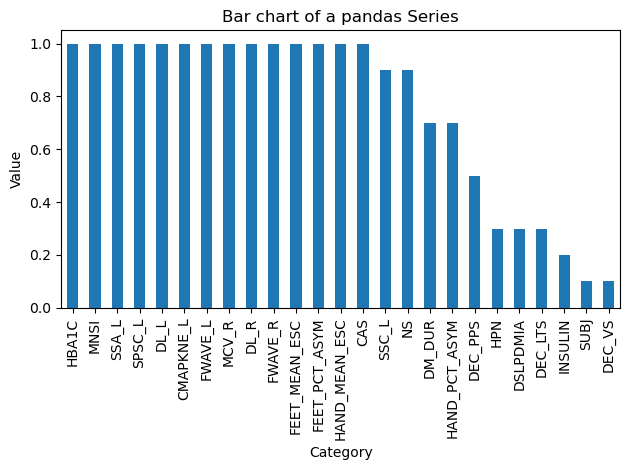

In [58]:
import matplotlib.pyplot as plt

s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.bar(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

In [59]:
imp = exp.local_feature_importance(query_instance, posthoc_sparsity_param=None)
df_imp = pd.DataFrame(imp.local_importance)
df_imp

100%|██████████| 1/1 [00:01<00:00,  1.52s/it]


,HBA1C,MNSI,SSA_L,SPSC_L,DL_L,CMAPKNE_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,CAS,SSC_L,HAND_MEAN_ESC,NS,DM_DUR,HAND_PCT_ASYM,INSULIN,DEC_PPS,SUBJ,HPN,DEC_LTS,SEX,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_AR
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.9,0.9,0.9,0.8,0.6,0.4,0.4,0.3,0.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


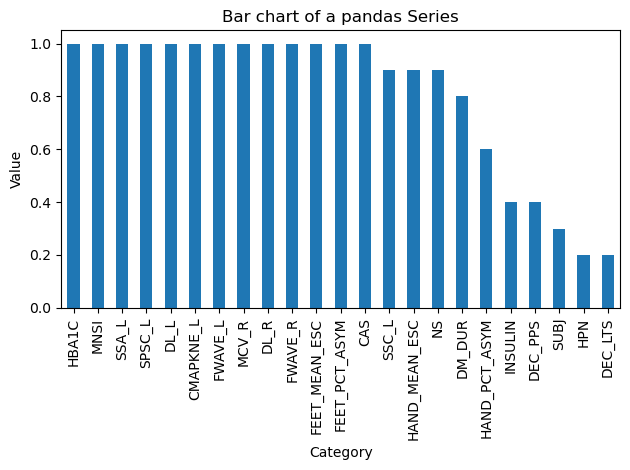

In [60]:
s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.bar(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

### Global Importance

In [72]:
cobj = exp.global_feature_importance(X_temp, total_CFs=10, posthoc_sparsity_param=None)
print(cobj.summary_importance)

100%|██████████| 190/190 [07:49<00:00,  2.47s/it]


{'CMAPKNE_L': 0.9989395546129375, 'FWAVE_R': 0.9941675503711559, 'FWAVE_L': 0.9899257688229056, 'MCV_R': 0.9893955461293743, 'SSA_L': 0.9830328738069989, 'HBA1C': 0.9819724284199364, 'FEET_MEAN_ESC': 0.9793213149522799, 'HAND_MEAN_ESC': 0.9782608695652174, 'DL_R': 0.9713679745493107, 'NS': 0.9676564156945917, 'DL_L': 0.9655355249204666, 'SSC_L': 0.9628844114528102, 'SPSC_L': 0.9522799575821845, 'CAS': 0.9459172852598091, 'FEET_PCT_ASYM': 0.9114528101802757, 'HAND_PCT_ASYM': 0.9093319194061505, 'DM_DUR': 0.8780487804878049, 'MNSI': 0.8441145281018028, 'DEC_VS': 0.30116648992576883, 'DEC_AR': 0.2608695652173913, 'INSULIN': 0.23223753976670203, 'SEX': 0.2264050901378579, 'DEC_LTS': 0.19247083775185578, 'DSLPDMIA': 0.1728525980911983, 'DEC_PPS': 0.15906680805938495, 'HPN': 0.13944856839872746, 'CKD': 0.1352067868504772, 'SUBJ': 0.1129374337221633, 'PAOD': 0.043478260869565216, 'GBS': 0.01166489925768823}


In [73]:
df_imp = pd.DataFrame([cobj.summary_importance])
df_imp

,CMAPKNE_L,FWAVE_R,FWAVE_L,MCV_R,SSA_L,HBA1C,FEET_MEAN_ESC,HAND_MEAN_ESC,DL_R,NS,DL_L,SSC_L,SPSC_L,CAS,FEET_PCT_ASYM,HAND_PCT_ASYM,DM_DUR,MNSI,DEC_VS,DEC_AR,INSULIN,SEX,DEC_LTS,DSLPDMIA,DEC_PPS,HPN,CKD,SUBJ,PAOD,GBS
0,0.999,0.994,0.99,0.989,0.983,0.982,0.979,0.978,0.971,0.968,0.966,0.963,0.952,0.946,0.911,0.909,0.878,0.844,0.301,0.261,0.232,0.226,0.192,0.173,0.159,0.139,0.135,0.113,0.043,0.012


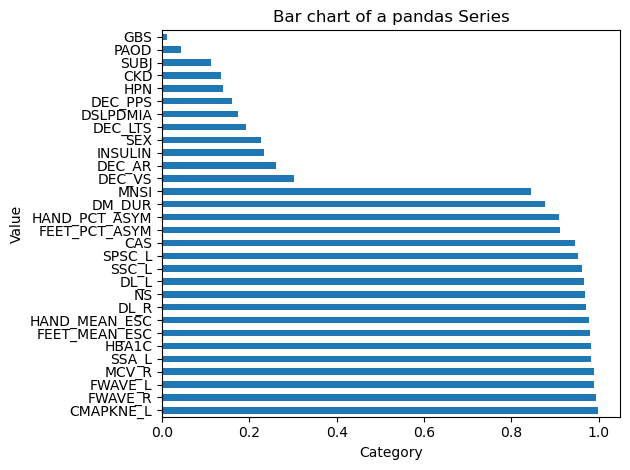

In [75]:
s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.barh(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

## Negative to Positive Counterfactuals
Analyze Real and Progressive Counterfactuals

In [84]:
cobj = exp.global_feature_importance(X_temp[y_temp==0], total_CFs=30, posthoc_sparsity_param=None)
print(cobj.summary_importance)

100%|██████████| 60/60 [05:02<00:00,  5.04s/it]


{'SSA_L': 1.0, 'CMAPKNE_L': 1.0, 'FWAVE_L': 0.9961024498886414, 'FWAVE_R': 0.9961024498886414, 'MCV_R': 0.9944320712694877, 'SSC_L': 0.9860801781737194, 'FEET_MEAN_ESC': 0.9844097995545658, 'HAND_MEAN_ESC': 0.9832962138084632, 'SPSC_L': 0.982739420935412, 'NS': 0.9749443207126949, 'HBA1C': 0.9721603563474388, 'DL_R': 0.9660356347438753, 'DL_L': 0.9582405345211581, 'CAS': 0.9565701559020044, 'HAND_PCT_ASYM': 0.9298440979955457, 'FEET_PCT_ASYM': 0.873608017817372, 'MNSI': 0.8307349665924276, 'DM_DUR': 0.7984409799554566, 'INSULIN': 0.22884187082405344, 'SEX': 0.21547884187082406, 'SUBJ': 0.2071269487750557, 'HPN': 0.13808463251670378, 'DEC_VS': 0.13140311804008908, 'DEC_LTS': 0.13140311804008908, 'DSLPDMIA': 0.1291759465478842, 'DEC_AR': 0.09855233853006681, 'DEC_PPS': 0.09688195991091314, 'CKD': 0.0801781737193764, 'PAOD': 0.021714922048997772, 'GBS': 0.011692650334075724}


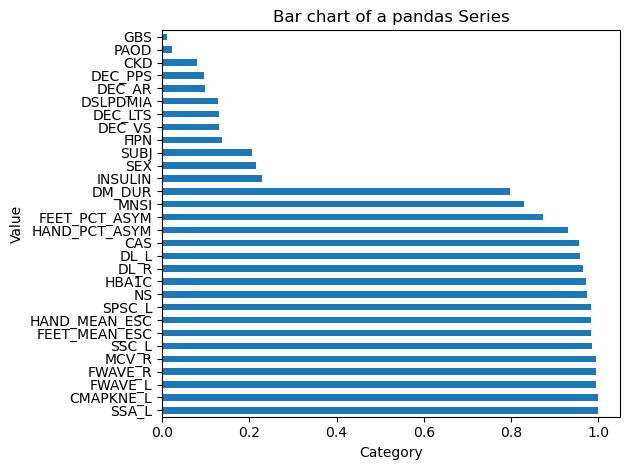

In [85]:
df_imp = pd.DataFrame([cobj.summary_importance])
s = df_imp.iloc[0]
s = s[s>0]

fig, ax = plt.subplots()
s.plot.barh(ax=ax)
ax.set_title("Bar chart of a pandas Series")
ax.set_xlabel("Category")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()